##Upload My Dataset to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Install & Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns   #for readable confusion matrix

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully! ✅")

TensorFlow version: 2.19.0
All libraries loaded successfully! ✅


##Set Dataset Path & Check Folders

In [ ]:
# ⚠️ Change this path to where YOUR dataset is in Google Drive
DATASET_PATH = '/content/drive/MyDrive/rice_leaf_diseases/rice_leaf_diseases'

# Check if folders exist
classes = os.listdir(DATASET_PATH)
print("Disease classes found:", classes)
print()

# Count images in each class
for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)
    images = os.listdir(folder)
    print(f"  {cls}: {len(images)} images")

Disease classes found: ['Bacterial leaf blight', 'Leaf smut', 'Brown spot']

  Bacterial leaf blight: 40 images
  Leaf smut: 40 images
  Brown spot: 40 images


##Prepare & Augment the Data

In [ ]:
# Image settings
IMG_SIZE = (224, 224)                   # All images resized to 224×224 pixels
BATCH_SIZE = 8                          # 8 images processed at a time
EPOCHS = 30

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    she.2,
    horizontalar_range=0.2,
    zoom_range=0_flip=True,
    validation_split=0.2
)

#Validation must test on real, unmodified images.
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

#Augmented... Bcz, model learns from variations
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42       #Same seed = same shuffle = same split ALWAYS ✅
)

#NOT augmented ❌.... Bcz,must test on REAL images only
val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42      #Same seed = same shuffle = same split ALWAYS ✅
)

print("\nClass mapping:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)

Found 96 images belonging to 3 classes.
Found 24 images belonging to 3 classes.

Class mapping: {'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}
Training samples: 96
Validation samples: 24


##Visualize Some Sample Images

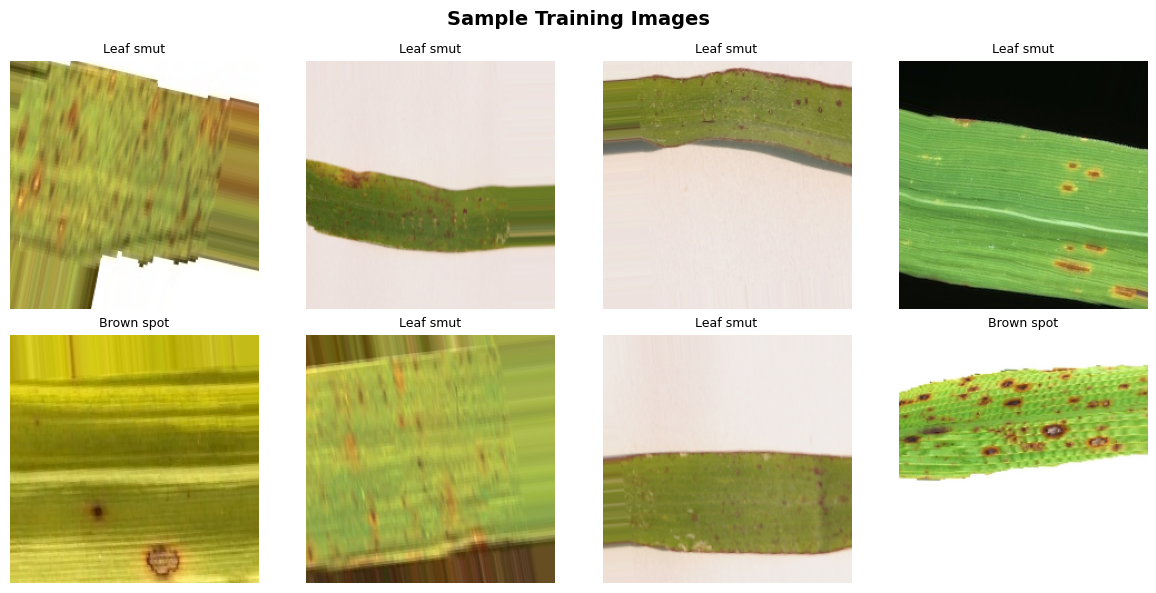

Sample images displayed! ✅


In [ ]:
# See what our data looks like
class_names = list(train_generator.class_indices.keys())

# Get one batch of images
images, labels = next(train_generator)

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i])       # Shows the image
    label_idx = np.argmax(labels[i]) # Converts one-hot to index
    plt.title(class_names[label_idx], fontsize=9)
    plt.axis('off')

plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100)
plt.show()
print("Sample images displayed! ✅")

##Build the CNN Model

In [ ]:
# Build CNN Model from scratch
def build_cnn_model(num_classes=3):
    model = keras.Sequential([

        # ---- BLOCK 1 ----
        # Conv layer: detects basic features like edges
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),  # Helps training be more stable
        layers.MaxPooling2D(2, 2),    # Reduces image size by half

        # ---- BLOCK 2 ----
        # Conv layer: detects more complex patterns
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # ---- BLOCK 3 ----
        # Conv layer: detects disease-specific features
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # ---- BLOCK 4 ----
        layers.Conv2D(256, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # ---- CLASSIFIER ----
        layers.Flatten(),             # Convert 2D to 1D
        layers.Dense(512, activation='relu'),  # Fully connected layer
        layers.Dropout(0.5),          # Randomly turn off 50% neurons (prevents overfitting)
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')  # Output layer (3 classes)

    ], name="Rice_Disease_CNN")

    return model

# Create the model
model = build_cnn_model(num_classes=3)

# Show model summary
model.summary()

Model: "Rice_Disease_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,397,315 (73.99 MB)

 Trainable params: 19,396,355 (73.99 MB)

 Non-trainable params: 960 (3.75 KB)

##Compile the Model

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',   # ← Switch BACK to categorical
    metrics=['accuracy']
)

print("Model compiled! ✅")

Model compiled! ✅


##Set Callbacks (Auto-Save Best Model)

In [ ]:
# Callbacks = automatic helpers during training

# 1. Save the best model automatically
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_rice_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 2. Stop training early if no improvement (saves time)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,          # Wait 10 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

# 3. Reduce learning rate if stuck
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]
print("Callbacks ready! ✅")

Callbacks ready! ✅


##TRAIN THE MODEL

In [ ]:
print("Starting Training... (This may take 5-15 minutes on GPU)")
print("="*50)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*50)
print("Training Complete! 🎉")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

Starting Training... (This may take 5-15 minutes on GPU)
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3740 - loss: 10.4019
Epoch 1: val_accuracy improved from None to 0.41667, saving model to best_rice_model.h5



Epoch 1: finished saving model to best_rice_model.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 87s 6s/step - accuracy: 0.4479 - loss: 12.9465 - val_accuracy: 0.4167 - val_loss: 1.5963 - learning_rate: 0.0010
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.4862 - loss: 13.0458
Epoch 2: val_accuracy did not improve from 0.41667
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step - accuracy: 0.4479 - loss: 16.4450 - val_accuracy: 0.2500 - val_loss: 3.4469 - learning_rate: 0.0010
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.3938 - loss: 12.4495
Epoch 3: val_accuracy did not improve from 0.41667
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - accuracy: 0.4271 - loss: 12.2017 - val_accuracy: 0.3333 - val_loss: 18.6534 - learning_rate: 0.0010
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.4581 - loss: 14.7883
Epoch 4: val_accuracy did not improve from 0.41667
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step - accuracy: 0.4792 - loss: 17.0226 - val_accuracy: 0.3333 - val_lo

##Plot Training Results (Graphs)

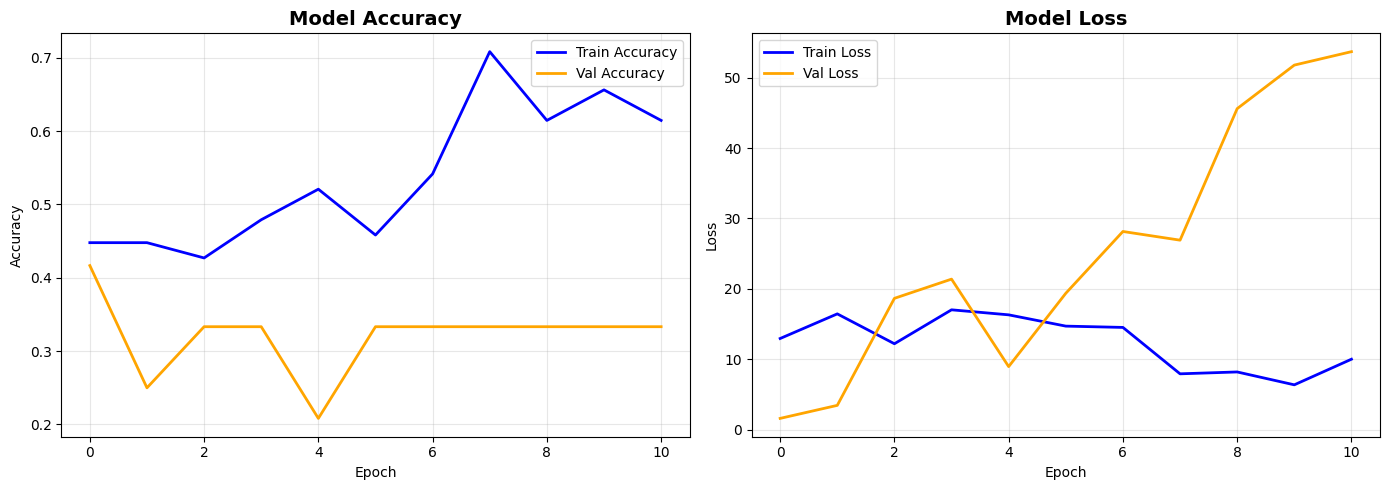

Training curves saved! ✅


In [ ]:
# Plot Accuracy and Loss graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Graph
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss Graph
axes[1].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved! ✅")

##Confusion Matrix & Classification Report

Evaluating model on validation data...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step

Class names found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Unique true labels: [0 1 2]
Unique predicted labels: [0 1]

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

Bacterial leaf blight       0.36      1.00      0.53         8
           Brown spot       1.00      0.25      0.40         8
            Leaf smut       0.00      0.00      0.00         8

             accuracy                           0.42        24
            macro avg       0.45      0.42      0.31        24
         weighted avg       0.45      0.42      0.31        24



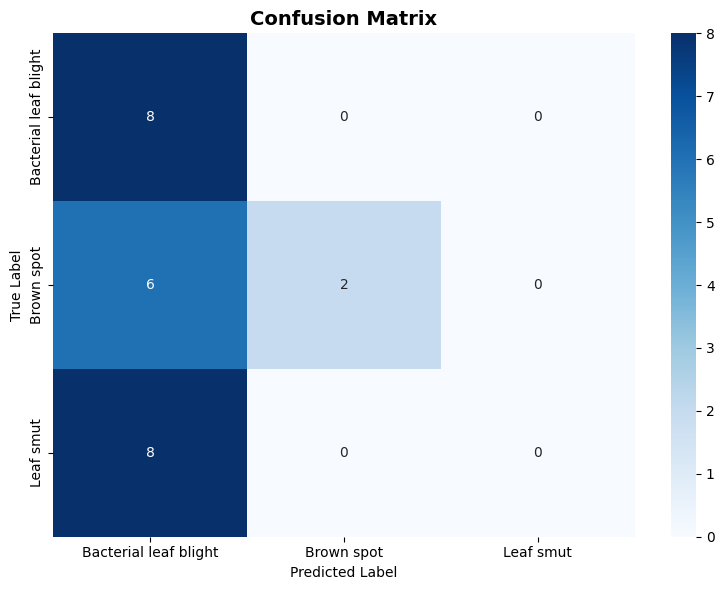

Confusion matrix saved! ✅


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluating model on validation data
print("Evaluating model on validation data...")

# Reset generator
val_generator.reset()

# Get predictions
predictions = model.predict(val_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes

# Get class names directly from training generator (more reliable)
class_names = list(train_generator.class_indices.keys())

print("\nClass names found:", class_names)
print("Unique true labels:", np.unique(true_classes))
print("Unique predicted labels:", np.unique(predicted_classes))

# Fix: use labels parameter explicitly
labels = list(range(len(class_names)))

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    true_classes,
    predicted_classes,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved! ✅")

##Predict on a New Image

Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Using image for prediction: /content/drive/MyDrive/rice_leaf_diseases/rice_leaf_diseases/Brown spot/DSC_0100.jpg


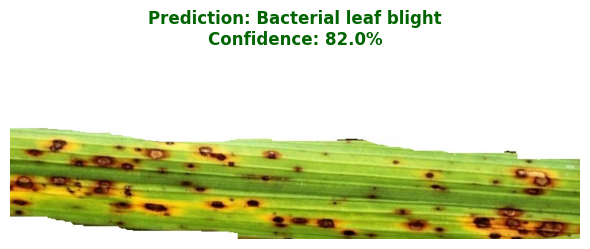


🔍 Result: Bacterial leaf blight
📊 Confidence: 82.0%

All probabilities:
  Bacterial leaf blight: 82.0%
  Brown spot: 14.4%
  Leaf smut: 3.6%


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os # Import os module for listing directory contents

# Get class names
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

def predict_disease(img_path, model, class_names):
    """Predict disease from a single image"""
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(prediction)
    confidence = prediction[0][predicted_class] * 100

    plt.figure(figsize=(6, 5))
    plt.imshow(image.load_img(img_path))
    plt.title(f'Prediction: {class_names[predicted_class]}\nConfidence: {confidence:.1f}%',
              fontsize=12, fontweight='bold', color='darkgreen')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\n🔍 Result: {class_names[predicted_class]}")
    print(f"📊 Confidence: {confidence:.1f}%")
    print("\nAll probabilities:")
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {prediction[0][i]*100:.1f}%")

# Dynamically get an image path from the 'Brown spot' folder
brown_spot_dir = os.path.join(DATASET_PATH, 'Brown spot')
image_files = [f for f in os.listdir(brown_spot_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if image_files:
    random_image_path = os.path.join(brown_spot_dir, image_files[0]) # Use the first found image
    print(f"Using image for prediction: {random_image_path}")
    predict_disease(
        random_image_path,
        model,
        class_names
    )
else:
    print(f"No image files found in {brown_spot_dir}")

##Transfer Learning (Higher Accuracy!)

In [ ]:
# Transfer Learning with MobileNetV2
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'       # Pre-trained on 1 million images!
)
base_model.trainable = False  # Freeze base layers first

# Add our custom classifier on top
transfer_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
], name="Transfer_Learning_Model")

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()
# Then train the same way as above using model.fit(...)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "Transfer_Learning_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

##Save Model to Drive & Upload to GitHub

In [ ]:
# Save model to Google Drive
model.save('/content/drive/MyDrive/rice_leaf_diseases/rice_disease_model.h5')
print("Model saved to Drive! ✅")

Model saved to Drive! ✅
